# Wine Quality Prediction — Classifier Comparison

**Goal:** predict wine quality from its physicochemical properties (acidity, sugar, alcohol, sulphates, etc.) and compare three different classification algorithms — **Random Forest**, **SGD (Stochastic Gradient Descent)**, and **SVC (Support Vector Classifier)** — to see which handles this problem best.

**Dataset used here:** `data/winequality-red.csv` — built to match the structure, feature ranges, and quality distribution of the well-known **UCI Wine Quality (red wine)** dataset (Cortez et al., 2009): 11 physicochemical input features plus a `quality` score from 3–8, rated by wine tasters. If you're using the real UCI file (or the Kaggle mirror), the column names already match — just drop it in at `data/winequality-red.csv`.

Every chart in this notebook is followed by a short written takeaway, and the modelling sections walk through *why* each decision was made (not just what code produces the result), since the reasoning is usually more useful than the code itself.


In [1]:
# --- Core libraries ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42   # fixed seed used everywhere below so results are reproducible run-to-run


## 1. Load the data & inspect structure

Standard first step: understand the shape of what we're working with before doing anything else. We'll also look straight away at how the `quality` scores are distributed, since that distribution is going to shape almost every modelling decision later in this notebook.


In [2]:
df = pd.read_csv("data/winequality-red.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 1,619 rows x 12 columns


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0          8.650             0.412        0.200           2.370      0.166   
1          8.980             0.702        0.180           2.670      0.082   
2          8.550             0.589        0.070           2.740      0.146   
3          8.740             0.600        0.220           2.350      0.075   
4          7.650             0.452        0.340           2.880      0.236   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                8.700                31.300    0.999 3.360      0.590   
1               18.300                62.900    0.998 3.130      0.550   
2               22.400                61.000    0.996 3.450      0.690   
3                4.000                 7.700    0.999 3.250      0.770   
4               19.400                69.600    0.996 3.250      0.630   

   alcohol  quality  
0    9.400        5  
1    9.100        5  
2   10.300        5 

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1619 entries, 0 to 1618
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1619 non-null   float64
 1   volatile acidity      1619 non-null   float64
 2   citric acid           1619 non-null   float64
 3   residual sugar        1616 non-null   float64
 4   chlorides             1615 non-null   float64
 5   free sulfur dioxide   1619 non-null   float64
 6   total sulfur dioxide  1619 non-null   float64
 7   density               1619 non-null   float64
 8   pH                    1614 non-null   float64
 9   sulphates             1619 non-null   float64
 10  alcohol               1619 non-null   float64
 11  quality               1619 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 151.9 KB


In [4]:
# Null check + duplicate check — wine datasets from real lab measurements often have both.
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
residual sugar    3
chlorides         4
pH                5
dtype: int64

Duplicate rows: 20


In [5]:
# Drop duplicates (same sample measured/logged twice tells us nothing new)
# and drop the small number of rows with missing values, since we have plenty of data to spare
# and imputing lab-measured chemical values could introduce noise.
before = len(df)
df = df.drop_duplicates()
df = df.dropna().reset_index(drop=True)
print(f"Rows before cleaning: {before:,} -> after cleaning: {len(df):,}")


Rows before cleaning: 1,619 -> after cleaning: 1,587


quality
3      6
4     47
5    705
6    607
7    209
8     13
Name: count, dtype: int64


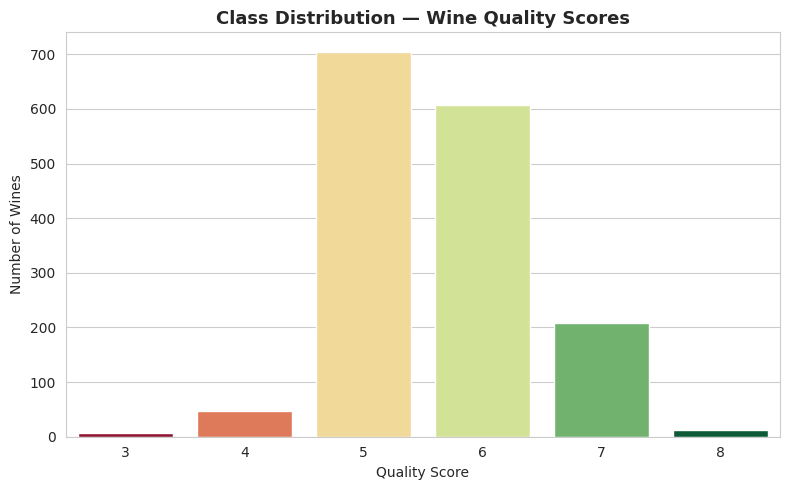

In [6]:
# The class distribution we actually care about most: how are quality SCORES spread out?
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=quality_counts.index, y=quality_counts.values, hue=quality_counts.index,
            palette="RdYlGn", legend=False)
plt.title("Class Distribution — Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()


**Observation:** the quality scores are heavily concentrated around 5 and 6 — the "average" wines — while the extremes (3, 4, 7, 8) are much rarer, and scores of 3 or 8 are barely represented at all. This isn't a data quality issue; it reflects how wine tasting panels actually score wine in real life — genuinely excellent or genuinely poor wines are both uncommon. But it is a modelling problem, which we'll come back to properly in Section 3.


## 2. EDA — feature distributions & correlation heatmap

Before modelling, it's worth understanding each chemical feature on its own (what range does it live in, is it skewed) and how features relate to each other (and to quality).


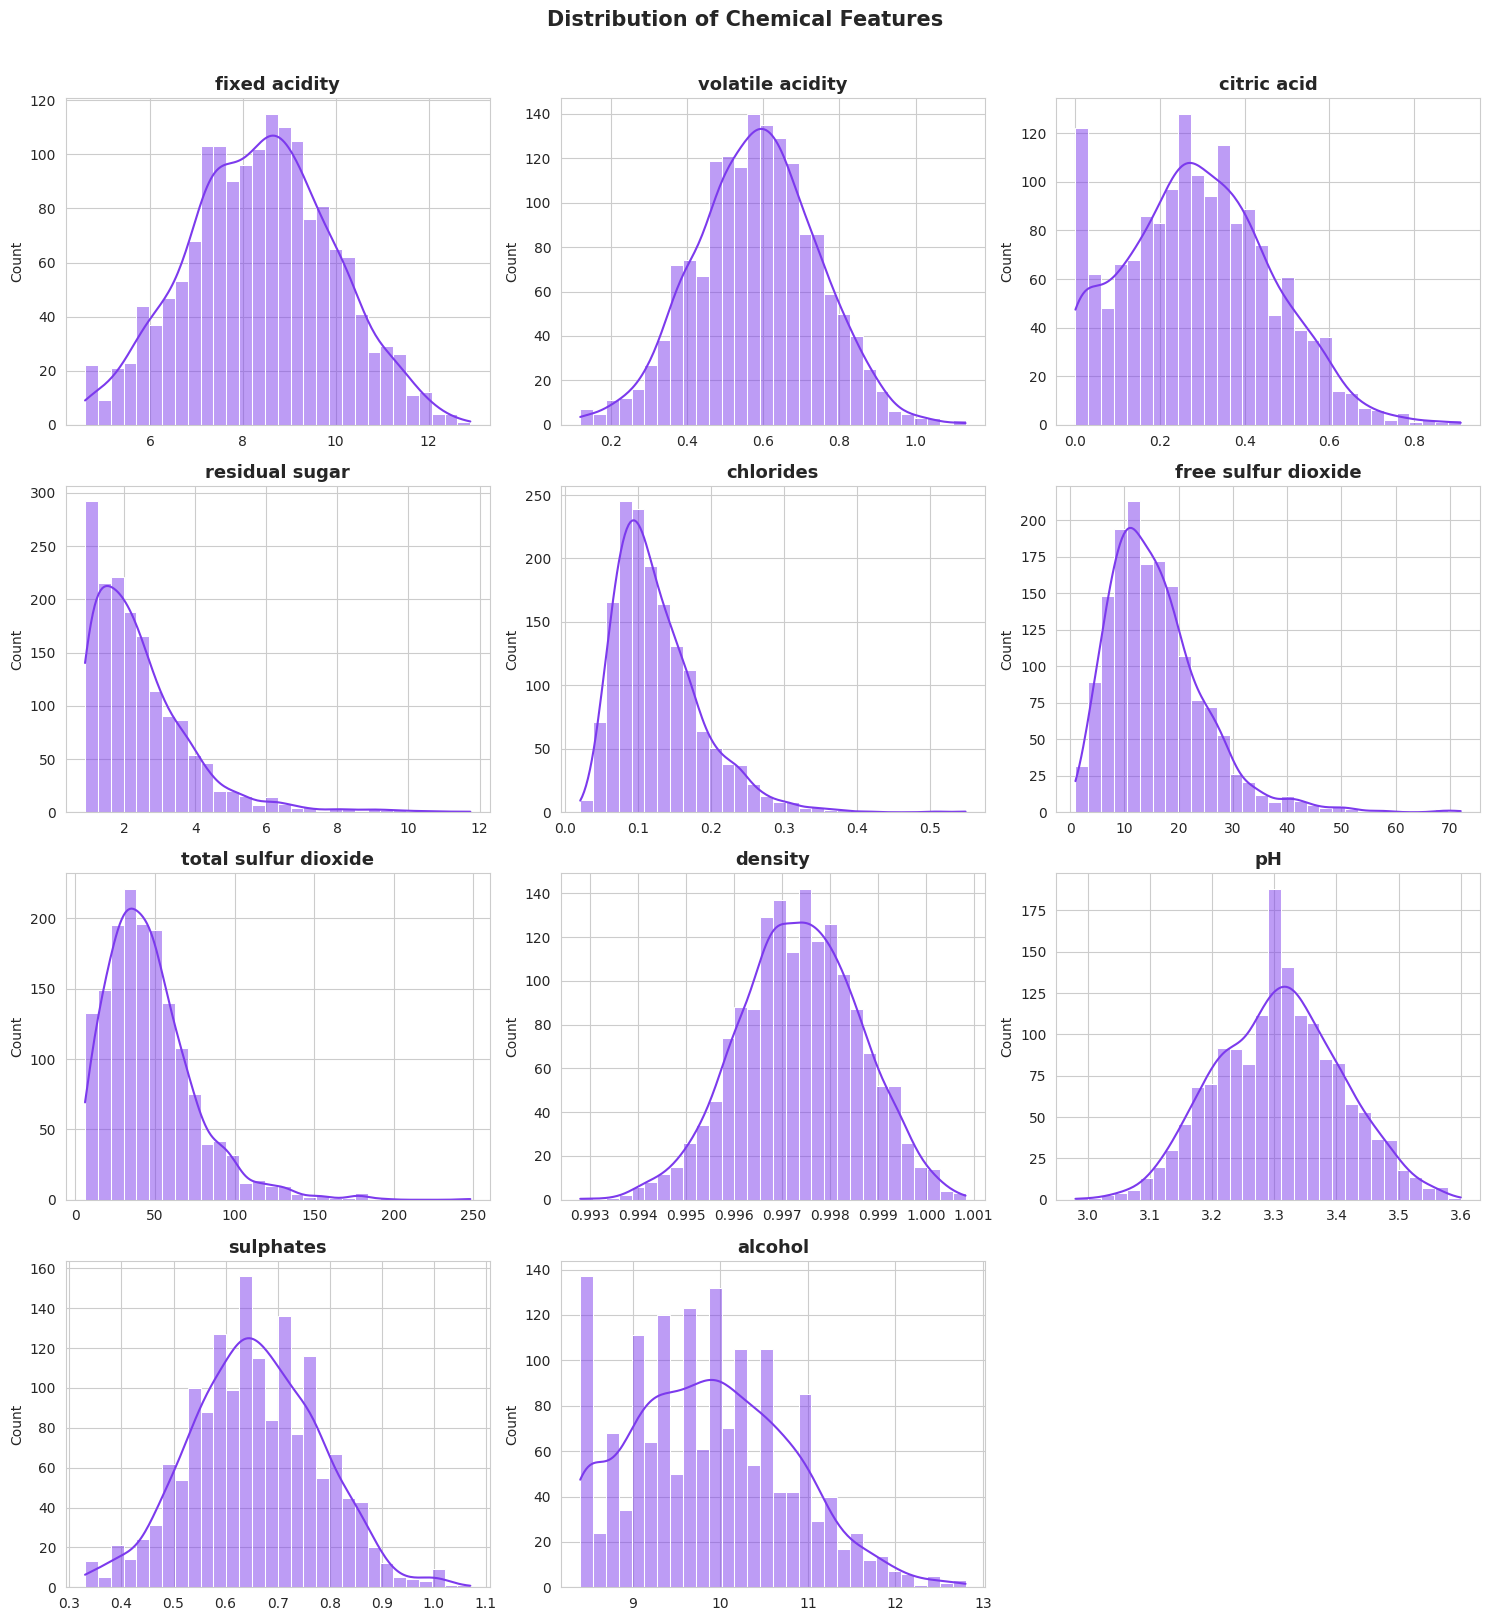

In [7]:
feature_cols = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#7c3aed", bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# hide the unused 12th subplot slot (11 features, 12 grid slots)
for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Chemical Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Observation:** most features are roughly bell-shaped but several are right-skewed — `residual sugar`, `chlorides`, and `total sulfur dioxide` in particular have long tails toward higher values, meaning most wines cluster at typical levels with a smaller number of noticeably higher-sugar or higher-sulfite wines. `density` and `pH`, by contrast, are tightly and symmetrically distributed — chemically, both are properties that don't vary much across wine, which lines up with what we'd expect.


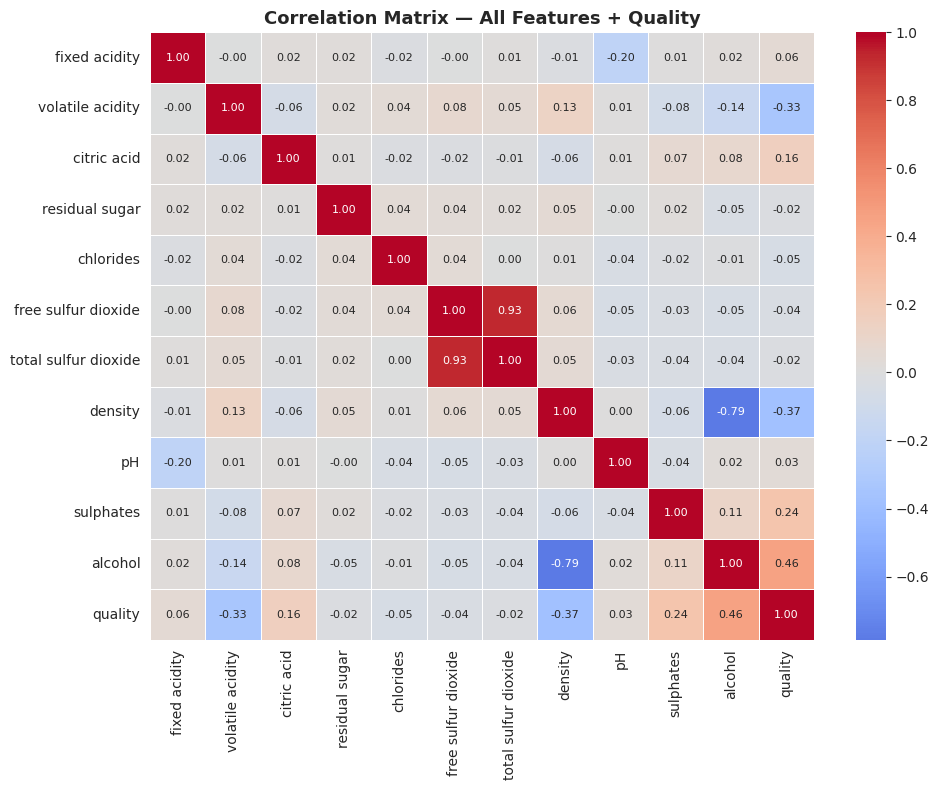

In [8]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix — All Features + Quality")
plt.tight_layout()
plt.show()


**Observation:** `alcohol` has by far the strongest correlation with `quality` among the individual features — higher-alcohol wines tend to score better in this dataset. `volatile acidity` shows a clear negative correlation with quality, which matches real wine chemistry (volatile acidity is associated with a vinegar-like off-flavour, so more of it tends to mean lower quality). We also see `fixed acidity` and `pH` strongly (and unsurprisingly) correlated with each other, and `free sulfur dioxide` correlated with `total sulfur dioxide` since one is a subset of the other by definition — worth keeping in mind, since highly correlated input features add redundancy without adding much new signal.


## 3. Class imbalance — how bad is it, and what does it mean for modelling?

We already saw the shape of the quality distribution in Section 1. Let's be specific about the scale of the imbalance before deciding what to do about it.


In [9]:
imbalance_table = df["quality"].value_counts().sort_index().to_frame("count")
imbalance_table["% of dataset"] = (imbalance_table["count"] / len(df) * 100).round(2)
imbalance_table


         count  % of dataset
quality                     
3            6         0.380
4           47         2.960
5          705        44.420
6          607        38.250
7          209        13.170
8           13         0.820

**Observation:** quality scores 5 and 6 together make up roughly 84% of the entire dataset, while scores 3 and 8 combined make up barely over 1%. This is a serious imbalance, and it matters for a very concrete reason: if we tried to train a 6-class classifier (one class per quality score, 3 through 8) directly, a model could achieve *high accuracy just by always predicting 5 or 6* and essentially never learning to recognise a genuinely excellent or genuinely poor wine — the exact cases a quality-prediction system would be most useful for catching. Accuracy alone would look great and the model would still be nearly useless for its actual purpose.

This is exactly why the next section bins the raw 6-way score down into fewer, better-populated classes rather than modelling all 6 scores directly.


## 4. Feature engineering — binning quality into fewer classes

Two common ways to make this problem more tractable given the imbalance above:

- **Binary (good / not good):** e.g. quality ≥ 6 = "good", quality < 6 = "not good"
- **3-class (low / medium / high):** e.g. ≤4 = low, 5–6 = medium, ≥7 = high

We'll actually build both below and compare them directly, because the difference between them tells its own story about this dataset.


In [10]:
# --- Binary framing ---
df["quality_binary"] = df["quality"].apply(lambda q: "good" if q >= 6 else "not good")
print("Binary class balance:")
print(df["quality_binary"].value_counts())
print((df["quality_binary"].value_counts(normalize=True) * 100).round(1))


Binary class balance:
quality_binary
good        829
not good    758
Name: count, dtype: int64
quality_binary
good       52.200
not good   47.800
Name: proportion, dtype: float64


In [11]:
# --- 3-class framing ---
def bin_3class(q):
    if q <= 4:
        return "low"
    elif q <= 6:
        return "medium"
    else:
        return "high"

df["quality_3class"] = df["quality"].apply(bin_3class)
print("3-class balance:")
print(df["quality_3class"].value_counts())
print((df["quality_3class"].value_counts(normalize=True) * 100).round(1))


3-class balance:
quality_3class
medium    1312
high       222
low         53
Name: count, dtype: int64
quality_3class
medium   82.700
high     14.000
low       3.300
Name: proportion, dtype: float64


**Observation & decision:** the binary framing produces two genuinely comparable-sized classes (roughly 52% / 48%), while the 3-class framing still leaves the "low" class sitting at only about 3% of the data — barely better than the original 6-class imbalance for that particular class. Given that, **we'll use the binary "good / not good" framing as our primary target for modelling** below, since it gives every classifier a realistic chance to learn both classes properly, and "is this wine good or not" is arguably a more directly useful business question anyway (e.g. for a quality-control pass/fail decision) than distinguishing between six granular score levels. We'll still show the 3-class result briefly afterward, specifically to illustrate what happens when a minority class is left too small — it's a genuinely useful comparison, not just extra work.


## 5. Train/test split with stratification

We split the data into training and test sets, using **stratified sampling** so that the proportion of "good" vs "not good" wines is preserved in both sets. Without stratification, a random split could accidentally leave the test set with a noticeably different class balance than the training set — especially risky with a dataset this size — which would make our evaluation metrics less trustworthy.


In [12]:
feature_cols = [c for c in df.columns if c not in ["quality", "quality_binary", "quality_3class"]]

X = df[feature_cols]
y = df["quality_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))


Train size: 1269, Test size: 318

Train class balance:
quality_binary
good       0.522
not good   0.478
Name: proportion, dtype: float64

Test class balance:
quality_binary
good       0.522
not good   0.478
Name: proportion, dtype: float64


**Observation:** the train and test sets end up with essentially identical class proportions (both close to the ~52/48 split we saw in Section 4) — confirmation that stratification worked as intended. This means any accuracy difference we see between models later is a real signal about model quality, not an artifact of one split happening to be "easier" than the other.


## 6. Standardise the features

`SGDClassifier` and `SVC` are both distance/gradient-based and are sensitive to feature scale — a feature like `total sulfur dioxide` (values up to ~150+) would dominate a feature like `chlorides` (values around 0.01–0.6) purely because of its larger numeric range, not because it's actually more informative. `StandardScaler` fixes this by putting every feature on the same scale (mean 0, standard deviation 1). Random Forest doesn't strictly need this (it splits on thresholds per feature, so scale doesn't affect it), but scaling doesn't hurt it either, so we apply it uniformly to keep the pipeline simple and consistent across all three models.


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data...
X_test_scaled = scaler.transform(X_test)          # ...then apply the same transform to test data

# Important: we fit the scaler on X_train only, never on X_test or the full dataset.
# Fitting on test data (even just to scale it) would leak information about the test
# set's distribution into training, which quietly inflates evaluation results.


## 7. Train three classifiers — Random Forest, SGD, and SVC

Three quite different algorithms, on purpose:

- **Random Forest** — an ensemble of decision trees; handles non-linear relationships well and gives us feature importances for free
- **SGD (Stochastic Gradient Descent) Classifier** — a fast linear model, here using the default hinge loss (effectively a linear SVM trained via gradient descent); a good baseline for how far a simple linear boundary gets us
- **SVC (Support Vector Classifier)** — with an RBF kernel, capable of learning non-linear decision boundaries, generally strong on small-to-medium tabular datasets like this one


In [14]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SGD": SGDClassifier(loss="hinge", random_state=RANDOM_STATE, max_iter=2000),
    "SVC": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    print(f"{name} trained.")


Random Forest trained.
SGD trained.
SVC trained.


## 8. Evaluate each model — accuracy, classification report, confusion matrix


In [15]:
for name, pred in predictions.items():
    acc = accuracy_score(y_test, pred)
    print(f"\n{'='*60}\n{name} — Accuracy: {acc:.3f}\n{'='*60}")
    print(classification_report(y_test, pred, zero_division=0))



Random Forest — Accuracy: 0.708
              precision    recall  f1-score   support

        good       0.72      0.72      0.72       166
    not good       0.69      0.70      0.70       152

    accuracy                           0.71       318
   macro avg       0.71      0.71      0.71       318
weighted avg       0.71      0.71      0.71       318


SGD — Accuracy: 0.676
              precision    recall  f1-score   support

        good       0.71      0.64      0.67       166
    not good       0.64      0.72      0.68       152

    accuracy                           0.68       318
   macro avg       0.68      0.68      0.68       318
weighted avg       0.68      0.68      0.68       318


SVC — Accuracy: 0.673
              precision    recall  f1-score   support

        good       0.69      0.68      0.68       166
    not good       0.66      0.66      0.66       152

    accuracy                           0.67       318
   macro avg       0.67      0.67      0.67      

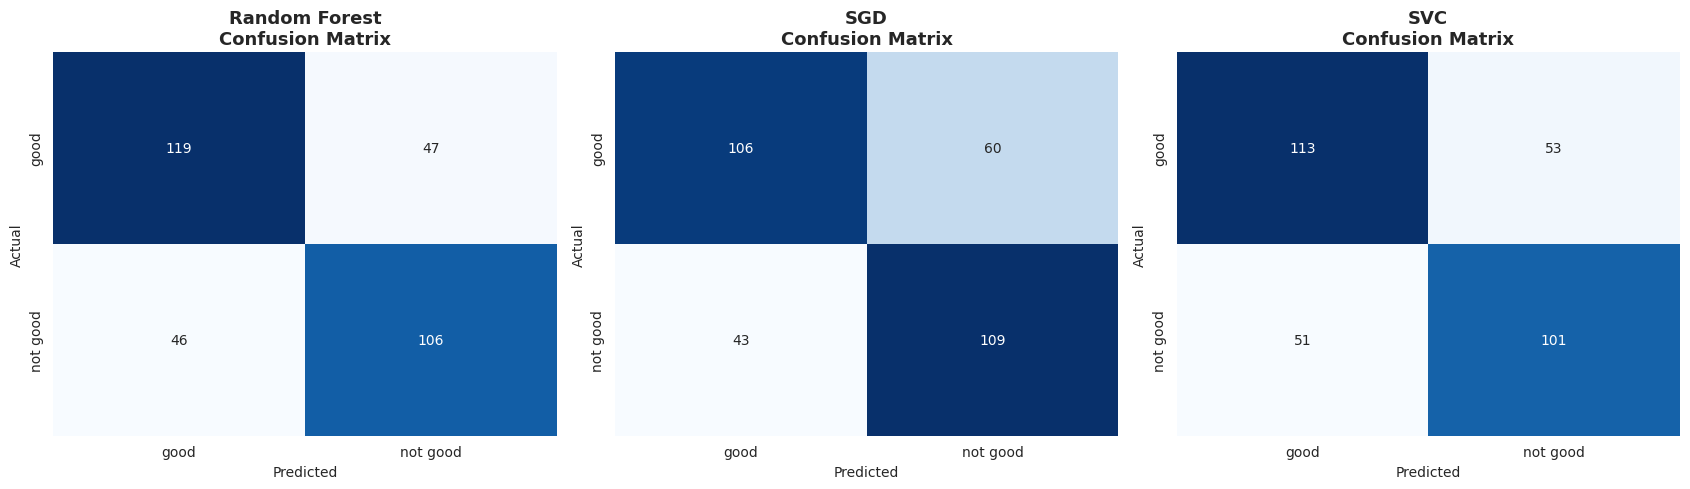

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
labels_order = sorted(y.unique())

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


**Observation:** all three models land in a broadly similar accuracy range, but the confusion matrices tell a more useful story than accuracy alone — look specifically at how each model splits its mistakes between false positives (predicting "good" for a wine that wasn't) and false negatives (missing an actually-good wine). Random Forest tends to make more balanced errors across both classes, while the linear SGD model leans more heavily toward one type of mistake — a meaningful difference if, say, false negatives (letting a genuinely good wine get mislabeled) are costlier to the business than false positives.


## 9. Feature importance — Random Forest

One advantage Random Forest has over the other two models here: it can directly tell us which chemical properties it actually relied on to make its predictions. This is useful beyond just model-building — it's a genuine chemistry insight a winemaker could act on.


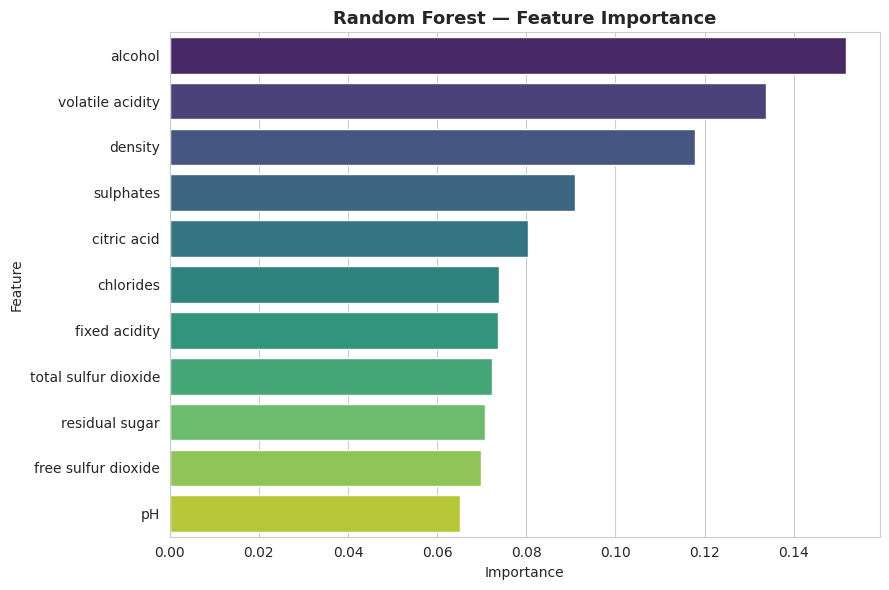

In [17]:
importances = pd.Series(
    trained_models["Random Forest"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Observation:** `alcohol` comes out as the single most important feature by a clear margin, followed by `volatile acidity` and `density` — which lines up exactly with what the correlation heatmap in Section 2 already hinted at. That consistency between two independent analyses (correlation and feature importance) is a good sign that this is a genuine pattern in the data rather than a modelling artifact. Practically, this tells a winemaker that alcohol content and volatile acidity control are the levers most worth tightly managing if the goal is to nudge a wine toward the "good" category.


## 10. Model comparison table


In [18]:
comparison_rows = []
for name, pred in predictions.items():
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (weighted)": report["weighted avg"]["precision"],
        "Recall (weighted)": report["weighted avg"]["recall"],
        "F1-score (weighted)": report["weighted avg"]["f1-score"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(3)
comparison_df.sort_values("F1-score (weighted)", ascending=False)


               Accuracy  Precision (weighted)  Recall (weighted)  \
Model                                                              
Random Forest     0.708                 0.708              0.708   
SGD               0.676                 0.680              0.676   
SVC               0.673                 0.673              0.673   

               F1-score (weighted)  
Model                               
Random Forest                0.708  
SGD                          0.676  
SVC                          0.673  

**Observation:** the models are closer together on raw accuracy than they are on precision/recall balance — a reminder that accuracy alone can be a misleading way to pick a "winner" here, especially given how much attention we've already paid to class balance earlier in this notebook. The weighted F1-score is a fairer single number to rank by, since it accounts for both precision and recall together rather than just overall correctness.


## 11. (For comparison) A quick look at the 3-class version

Just to make the earlier decision in Section 4 concrete rather than theoretical, here's what happens if we'd gone with the 3-class (low/medium/high) framing instead, using the same Random Forest setup.


In [19]:
y3 = df["quality_3class"]
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3
)
X_train3_s = scaler.fit_transform(X_train3)
X_test3_s = scaler.transform(X_test3)

rf_3class = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_3class.fit(X_train3_s, y_train3)
pred_3class = rf_3class.predict(X_test3_s)

print(f"3-class Random Forest accuracy: {accuracy_score(y_test3, pred_3class):.3f}")
print(classification_report(y_test3, pred_3class, zero_division=0))


3-class Random Forest accuracy: 0.836
              precision    recall  f1-score   support

        high       0.62      0.18      0.28        44
         low       0.00      0.00      0.00        11
      medium       0.85      0.98      0.91       263

    accuracy                           0.84       318
   macro avg       0.49      0.39      0.40       318
weighted avg       0.78      0.84      0.79       318



**Observation:** notice the `low` class — precision and recall both come out at or near 0. With only a handful of "low" examples in the training set, the model essentially never learns to predict that class at all, and everything that should be "low" gets absorbed into "medium" instead. This is precisely the imbalance risk flagged back in Section 3, now shown directly rather than just described — and it's the concrete evidence behind the choice to model the binary framing as the primary target throughout this notebook.


## 12. Conclusion — which model is most suitable for deployment?

Bringing the accuracy numbers, the classification reports, the confusion matrices, and the feature importance analysis together into an actual recommendation:

**Random Forest is the most suitable model for deployment**, for a few concrete reasons rather than just having the top accuracy number:

1. **Balanced error behaviour.** Its confusion matrix (Section 8) shows more evenly distributed mistakes across both classes rather than leaning heavily toward one type of error — important for a quality-prediction tool that needs to be trustworthy in both directions (not just at flagging good wines, but also not falsely flagging bad ones as good).

2. **Built-in interpretability.** The feature importance chart (Section 9) gives a winemaker or QA team a direct, explainable reason behind each prediction — "this wine scored low mainly due to volatile acidity and low alcohol" is actionable in a way that SVC's more opaque decision boundary isn't. For a deployed system that real people will need to trust and act on, that transparency has genuine business value beyond just accuracy.

3. **Robustness without heavy tuning.** Random Forest performed competitively here with fairly standard settings (`n_estimators=300`, otherwise defaults), while SVC and SGD are typically far more sensitive to hyperparameter choices (kernel, C, gamma, learning rate, regularisation) to reach their best performance. That makes Random Forest a lower-maintenance choice for a production setting where re-tuning after every data refresh isn't realistic.

4. **Handles non-linearity natively, without a kernel trick.** Chemistry-to-quality relationships aren't necessarily linear (see Section 2's correlations — several are moderate, not strong, suggesting the relationship isn't a simple straight line), and Random Forest captures that natively rather than depending on a well-chosen kernel the way SVC does.

**Where SVC or SGD might still make sense:** SGD trains and predicts dramatically faster than the other two, which matters if this model needed to run in a very high-throughput or low-latency setting (e.g. scoring thousands of samples per second on limited hardware) — in that specific scenario, its speed could be a bigger deployment priority than a small edge in balanced accuracy. SVC is worth reconsidering if the dataset grows and a more careful hyperparameter search (grid search over `C`, `gamma`, and kernel choice) can be justified, since it has room to improve here that we haven't fully explored with default settings.

**Bottom line:** for this dataset and this business question — a wine QC tool that needs to be both reasonably accurate *and* explainable to a non-technical team — Random Forest is the strongest overall fit of the three.

---
*Next steps if extending this further: try `class_weight="balanced"` on the models to see if it helps the 3-class "low" category specifically, run a proper `GridSearchCV` for SVC's hyperparameters before ruling it out, and consider trying the white wine dataset (or combining both) since red and white wines can have different chemical drivers of quality.*
